In [1]:
import pandas as pd
import numpy as np

review = pd.read_pickle('review.pkl')

In [33]:
# Step 1: Create 'rating_int' column
review['rating_int'] = review['rating'].round().astype(int)

# Step 2: Define how many samples per group
N_PER_GROUP = 5000 # adjust based on data size

# Step 3: Drop missing embeddings and filter to valid ratings
filtered = review.dropna(subset=['embedding_array'])
filtered = filtered[filtered['rating_int'].between(1, 5)]

# Step 4: Balanced sampling by (product_category, rating_int)
balanced_subset = (
    filtered.groupby(['product_category', 'rating_int'], group_keys=False)
    .apply(lambda x: x.sample(min(len(x), N_PER_GROUP), random_state=42))
    .reset_index(drop=True)
)

# Step 5: Check group sizes
group_sizes = balanced_subset.groupby(['product_category', 'rating_int']).size().unstack()
print(group_sizes)


rating_int                    1    2    3     4     5
product_category                                     
All_Beauty                  360  276  500  1000  2864
Books                       111  214  536  1102  3037
Clothing_Shoes_and_Jewelry  241  195  453   976  3135
Electronics                 395  196  326   812  3271
Home_and_Kitchen            257  140  355   709  3539


C:\Windows\Temp\ipykernel_21816\2921547701.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), N_PER_GROUP), random_state=42))


In [30]:
balanced_subset.to_pickle("balanced_subset.pkl")

In [31]:
balanced_subset = pd.read_pickle('balanced_subset.pkl')
balanced_subset.head()

,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase,product_category,full_text,embedding,embedding_array,rating_int
0,1.0,waste,Absolutely Nothing !,[],B016P7WU2W,B016P7WU2W,AGAGNT4LRMYAIWWU3WW5GEUM7XYQ,1471539483000,0,True,All_Beauty,waste Absolutely Nothing !,"[0.022893041, 0.11033335, 0.009343361, -0.0085...","[0.022893041, 0.11033335, 0.009343361, -0.0085...",1
1,1.0,Not practical,I would not recommend this comb. It smells awf...,[],B01KDPA96G,B01KDPA96G,AFJVYJ75233DFO3FZYXTELUZLUGA,1552095858684,0,True,All_Beauty,Not practical I would not recommend this comb....,"[-0.08551035, 0.01128329, -0.0037824116, 0.038...","[-0.08551035, 0.01128329, -0.0037824116, 0.038...",1
2,1.0,NOPE,No. Returned.,[],B01MR76X6K,B01MR76X6K,AF3IINICLZX6NXMOMS5ENPDXBDBQ,1497286044817,0,True,All_Beauty,NOPE No. Returned.,"[-0.03155846, 0.02007257, -0.005148607, 0.0665...","[-0.03155846, 0.02007257, -0.005148607, 0.0665...",1
3,1.0,"If it seems too good to be true, it probably is",Lesson learned with this product. Too many 5 s...,[],B012Q9NGE4,B012Q9NGE4,AHA2GWISWCYDNZY6SRNXAEQDSOZA,1457669014000,7,True,All_Beauty,"If it seems too good to be true, it probably i...","[-0.06414388, -0.110667914, 0.03958494, -0.002...","[-0.06414388, -0.110667914, 0.03958494, -0.002...",1
4,1.0,Not impressed with the quality.,This Acrylic Nail Brush Set would have been ni...,[],B09B4V77YH,B09B4V77YH,AF453YWNMOPDI5XRRVQOIF56NM4Q,1639856957547,0,False,All_Beauty,Not impressed with the quality. This Acrylic N...,"[-0.10638394, 0.017915852, 0.041937687, -0.011...","[-0.10638394, 0.017915852, 0.041937687, -0.011...",1


In [22]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Filter & Prepare
df = subset.dropna(subset=['rating', 'embedding_array'])
X = np.vstack(df['embedding_array'].values)
y = df['rating'].values

# Optional: Normalize embeddings
#scaler = StandardScaler()
#X_scaled = scaler.fit_transform(X)

# 2. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# 3. Regression Models
models = {
    'LinearRegression': make_pipeline(StandardScaler(), LinearRegression()),
    'RandomForest': RandomForestRegressor(
        n_estimators=50,  # Fewer trees (default: 100)
        max_depth=10,     # Limit tree depth (default: None)
        min_samples_split=5,  # Reduce splits
        n_jobs=-1,        # Use all CPU cores
        random_state=42,
        verbose=2
    )
}

results = {}

for name, model in models.items():
    # Fit and predict
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    results[name] = preds
    
    # Cross-validation
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='neg_mean_absolute_error')
    
    # Evaluation
    print(f"\n{name}")
    print("CV MAE:", -cv_scores.mean(), "±", cv_scores.std())
    print("MAE:", mean_absolute_error(y_test, preds))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, preds)))
    print("R²:", r2_score(y_test, preds))
    print("Within 0.5 stars:", np.mean(np.abs(preds - y_test) <= 0.5))

In [23]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler

# Scale data (critical for SVR!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train SVR
model = SVR(kernel='rbf', C=1.0, epsilon=0.1)
model.fit(X_train_scaled, y_train)

# Predict
preds = model.predict(X_test_scaled)
print("MAE:", mean_absolute_error(y_test, preds))
print("RMSE:", np.sqrt(mean_squared_error(y_test, preds)))
print("Within 0.5 stars:", np.mean(np.abs(preds - y_test) <= 0.5))

MAE: 0.678716206183991
RMSE: 0.8937963317467151
Within 0.5 stars: 0.47314123087869087


In [ ]:

# 3. Regression Models
models = {
    'LinearRegression': LinearRegression(),
    'RandomForest': RandomForestRegressor(random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    results[name] = preds
    print(f"\n{name}")
    print("MAE:", mean_absolute_error(y_test, preds))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, preds)))
    print("Within 0.5 stars:", np.mean(np.abs(preds - y_test) <= 0.5))



#### retry

In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk

# Download sentiment lexicon (if not already done)
nltk.download('vader_lexicon')
sia = SentimentIntensityAnalyzer()

# ----- FEATURE ENGINEERING -----

# 1. Review length
review['review_length'] = review['full_text'].apply(lambda x: len(x.split()))

# 2. Sentiment score
review['sentiment_score'] = review['full_text'].apply(lambda x: sia.polarity_scores(x)['compound'])

# 3. Helpful votes (fill NaN with 0). try log normalization
review['helpful_vote_log'] = np.log1p(review['helpful_vote'])

# Stack embeddings + new features
X_embed = np.vstack(review['embedding_array'].values)
features_to_add = review[['review_length', 'sentiment_score', 'helpful_vote_log']].values
X_final = np.hstack((X_embed, features_to_add))
y = review['rating'].values

# ----- TRAIN-TEST SPLIT -----
X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.2, random_state=42)

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\司瑾洋\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [ ]:


# ----- MODELS & EVALUATION -----
from sklearn.svm import SVR

# ----- MODELS: Linear + SVR -----
models = {
    'LinearRegression': make_pipeline(StandardScaler(), LinearRegression()),
    'SVR': make_pipeline(StandardScaler(), SVR(kernel='rbf', C=1.0, epsilon=0.2))
}

for name, model in models.items():
    # Fit and predict
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    # Cross-validation MAE
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)

    print(f"\n{name}")
    print("CV MAE:", -cv_scores.mean(), "±", cv_scores.std())
    print("MAE:", mean_absolute_error(y_test, preds))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, preds)))
    print("R²:", r2_score(y_test, preds))
    print("Within 1 stars:", np.mean(np.abs(preds - y_test) <= 1))




LinearRegression
CV MAE: 0.638048150356424 ± 0.011295339907444855
MAE: 0.6342453752830414
RMSE: 0.8413432170182922
R²: 0.4226094710606927
Within 1 stars: 0.8048


#### now try LinearSVR + PCA with GridSearch CV

In [4]:
from sklearn.decomposition import PCA
from sklearn.svm import LinearSVR
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# ----- PCA on Embeddings -----
pca = PCA(n_components=100, random_state=42)
X_embed_reduced = pca.fit_transform(X_embed)

# ----- Final Feature Set -----
X_final = np.hstack((X_embed_reduced, features_to_add))

# ----- Train-Test Split -----
X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.2, random_state=42)

# ----- Pipeline with GridSearch -----
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svr', LinearSVR(max_iter=5000, random_state=42))
])

param_grid = {
    'svr__C': [0.1, 1.0, 10],
    'svr__epsilon': [0.1, 0.2, 0.3]
}

grid = GridSearchCV(pipeline, param_grid, scoring='neg_mean_absolute_error', cv=3, n_jobs=-1, verbose=2)
grid.fit(X_train, y_train)

# ----- Evaluation -----
best_model = grid.best_estimator_
preds = best_model.predict(X_test)

print("\nBest Params:", grid.best_params_)
print("MAE:", mean_absolute_error(y_test, preds))
print("RMSE:", np.sqrt(mean_squared_error(y_test, preds)))
print("R²:", r2_score(y_test, preds))
print("Within 1 stars:", np.mean(np.abs(preds - y_test) <= 1))


Fitting 3 folds for each of 9 candidates, totalling 27 fits

Best Params: {'svr__C': 1.0, 'svr__epsilon': 0.1}
MAE: 0.5952142543720595
RMSE: 0.8765820567821039
R²: 0.37322969340177226
Within 1 stars: 0.8118


d:\miniconda\envs\data_engineering\Lib\site-packages\sklearn\svm\_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ----- Use rounded rating as classification labels -----
y_class = np.round(y).astype(int)

# Train-test split (same features as regression)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_final, y_class, test_size=0.2, random_state=42)

Fitting 3 folds for each of 4 candidates, totalling 12 fits


d:\miniconda\envs\data_engineering\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Best Params: {'logreg__C': 10, 'logreg__penalty': 'l2'}
Accuracy: 0.6922

Classification Report:
               precision    recall  f1-score   support

           1       0.54      0.61      0.57       246
           2       0.28      0.09      0.14       203
           3       0.34      0.21      0.26       421
           4       0.39      0.14      0.20       878
           5       0.75      0.95      0.84      3252

    accuracy                           0.69      5000
   macro avg       0.46      0.40      0.40      5000
weighted avg       0.63      0.69      0.64      5000



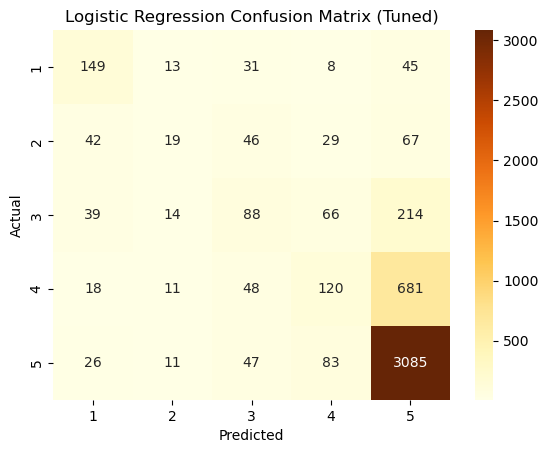

In [10]:
# 4. Compare with Classification
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Pipeline
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(max_iter=1000, multi_class='multinomial', solver='lbfgs'))
])

# Param grid
param_grid = {
    'logreg__C': [0.1, 1, 10, 100],
    'logreg__penalty': ['l2']  # lbfgs only supports L2
}

# GridSearch
grid = GridSearchCV(pipe, param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=2)
grid.fit(X_train_c, y_train_c)

# Evaluation
best_clf = grid.best_estimator_
y_pred_best = best_clf.predict(X_test_c)

print("Best Params:", grid.best_params_)
print("Accuracy:", accuracy_score(y_test_c, y_pred_best))
print("\nClassification Report:\n", classification_report(y_test_c, y_pred_best))

# Confusion Matrix
cm = confusion_matrix(y_test_c, y_pred_best, labels=[1, 2, 3, 4, 5])
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrBr', xticklabels=[1,2,3,4,5], yticklabels=[1,2,3,4,5])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix (Tuned)")
plt.show()



In [2]:
import numpy as np

A = np.array([[0.7, 0.8], [0.9, 1]])
U, S, VT = np.linalg.svd(A)

print("Singular values:", S)

Singular values: [1.71460314 0.01166451]
